# A2: Loss Functions and the Training Criterion

MLP on MNIST, comparing training criteria (loss functions): cross entropy,
squared error, absolute error, label smoothing, and my own expected-cost
criterion built from a reward matrix.

* Input: a 28x28 image, flattened to 784 values and scaled to [0, 1].
* Output: a probability vector of length 10.

In [1]:
import os
import gzip
import json
import time
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

## 1. Load MNIST

In [2]:
MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
MNIST_FILES = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz",
]


def download_mnist(data_dir="data"):
    os.makedirs(data_dir, exist_ok=True)
    for fname in MNIST_FILES:
        path = os.path.join(data_dir, fname)
        if not os.path.exists(path):
            print("downloading", fname)
            urllib.request.urlretrieve(MNIST_URL + fname, path)
    return data_dir


def load_idx_images(path):
    with gzip.open(path, "rb") as f:
        magic, n, rows, cols = np.frombuffer(f.read(16), dtype=">u4")
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(int(n), int(rows), int(cols)).copy()
    return data


def load_idx_labels(path):
    with gzip.open(path, "rb") as f:
        magic, n = np.frombuffer(f.read(8), dtype=">u4")
        data = np.frombuffer(f.read(), dtype=np.uint8).copy()
    return data


def load_mnist(data_dir="data"):
    data_dir = download_mnist(data_dir)
    train_images = load_idx_images(os.path.join(data_dir, "train-images-idx3-ubyte.gz"))
    train_labels = load_idx_labels(os.path.join(data_dir, "train-labels-idx1-ubyte.gz"))
    test_images = load_idx_images(os.path.join(data_dir, "t10k-images-idx3-ubyte.gz"))
    test_labels = load_idx_labels(os.path.join(data_dir, "t10k-labels-idx1-ubyte.gz"))
    return train_images, train_labels, test_images, test_labels


X_train, y_train, X_test, y_test = load_mnist()
print("train", X_train.shape, y_train.shape)
print("test", X_test.shape, y_test.shape)

train (60000, 28, 28) (60000,)
test (10000, 28, 28) (10000,)


## 2. Configuration and Preprocessing

In [3]:
In_size = 28 * 28
H1_size = 128
H2_size = 128
Output_size = 10
learning_rate = 0.001
beta1, beta2, eps = 0.9, 0.999, 1e-8
epochs = 30
batch_size = 128
number_of_folds = 5
label_smooth = 0.1
seeds = [42, 0, 1]

X_train_normalised = np.reshape(X_train / 255.0, (np.size(X_train, axis=0), -1))
X_test_normalised = np.reshape(X_test / 255.0, (np.size(X_test, axis=0), -1))
N = len(X_train_normalised)

onehot = np.eye(10)
smooth_targets = (1 - label_smooth) * np.eye(10) + label_smooth / 10

## 3. The Training Criteria

my own criterion uses a reward matrix. rows are the true digit, columns the guess.
bigger value = more similar = less cost for that guess. diagonal is 10 (correct),
visually similar digits get up to 6. divided by 10 so the reward is in [0,1].

In [4]:
reward_matrix = np.array([
    [10, 0, 1, 1, 0, 1, 2, 0, 1, 1],   # 0
    [0, 10, 1, 1, 1, 0, 0, 1, 2, 0],   # 1
    [1, 1, 10, 3, 1, 1, 1, 3, 3, 0],   # 2
    [1, 1, 3, 10, 0, 5, 0, 2, 4, 2],   # 3
    [0, 1, 1, 0, 10, 1, 2, 2, 1, 6],   # 4
    [1, 0, 1, 5, 1, 10, 3, 0, 3, 2],   # 5
    [2, 0, 1, 0, 2, 3, 10, 0, 2, 0],   # 6
    [0, 1, 3, 2, 2, 0, 0, 10, 1, 4],   # 7
    [1, 2, 3, 4, 1, 3, 2, 1, 10, 2],   # 8
    [1, 0, 0, 2, 6, 2, 0, 4, 2, 10],   # 9
]) / 10

criteria = ["cross entropy", "squared error", "absolute error", "label smoothing", "my reward"]

## 4. Training

tanh hidden layers (the activation from the module), lecun normal init (variance
1/fan_in, the right choice for tanh), minibatch adam. the criterion is picked inline.

In [5]:
def run(criterion, run_X, run_y, val_X=None, val_y=None, seed=42):
    np.random.seed(seed)
    H1_weights = np.random.normal(0, np.sqrt(1 / In_size), (H1_size, In_size))
    H1_bias = np.zeros(H1_size)
    H2_weights = np.random.normal(0, np.sqrt(1 / H1_size), (H2_size, H1_size))
    H2_bias = np.zeros(H2_size)
    Output_weights = np.random.normal(0, np.sqrt(1 / H2_size), (Output_size, H2_size))
    Output_bias = np.zeros(Output_size)

    params = {"W1": H1_weights, "b1": H1_bias,
              "W2": H2_weights, "b2": H2_bias,
              "Wo": Output_weights, "bo": Output_bias}
    m = {k: np.zeros_like(p) for k, p in params.items()}
    v = {k: np.zeros_like(p) for k, p in params.items()}
    t = 0
    number_in_run = len(run_X)
    epoch_train_ces = []
    epoch_val_losses = []
    epoch_val_accs = []

    for epoch in range(epochs):
        order = np.random.permutation(number_in_run)
        batch_ces = []
        for start in range(0, number_in_run, batch_size):
            idx = order[start:start + batch_size]
            a0 = run_X[idx]
            yb = run_y[idx]
            n = len(idx)

            # forward
            z1 = a0 @ H1_weights.T + H1_bias
            a1 = np.tanh(z1)
            z2 = a1 @ H2_weights.T + H2_bias
            a2 = np.tanh(z2)
            z3 = a2 @ Output_weights.T + Output_bias
            exp_z = np.exp(z3 - z3.max(axis=1, keepdims=True))
            p = exp_z / exp_z.sum(axis=1, keepdims=True)
            ce_batch = -np.sum(onehot[yb] * np.log(p + 1e-8)) / n

            # criterion (inline)
            if criterion == "cross entropy":
                tgt = onehot[yb]
                loss = -np.sum(tgt * np.log(p + 1e-8)) / n
                d3 = (p - tgt) / n
            elif criterion == "squared error":
                r = p - onehot[yb]
                loss = np.sum(0.5 * r ** 2) / n
                d3 = p * (r - np.sum(r * p, axis=1, keepdims=True)) / n
            elif criterion == "absolute error":
                r = p - onehot[yb]
                loss = np.sum(np.abs(r)) / n
                s = np.sign(r)
                d3 = p * (s - np.sum(s * p, axis=1, keepdims=True)) / n
            elif criterion == "label smoothing":
                tgt = smooth_targets[yb]
                loss = -np.sum(tgt * np.log(p + 1e-8)) / n
                d3 = (p - tgt) / n
            elif criterion == "my reward":
                cost = 1 - reward_matrix[yb]
                loss = np.sum(p * cost) / n
                d3 = p * (cost - np.sum(p * cost, axis=1, keepdims=True)) / n
            batch_ces.append(ce_batch)

            # backward (all gradients first)
            d2 = (d3 @ Output_weights) * (1 - np.tanh(z2) ** 2)
            d1 = (d2 @ H2_weights) * (1 - np.tanh(z1) ** 2)
            grads = {"Wo": d3.T @ a2, "bo": d3.sum(axis=0),
                     "W2": d2.T @ a1, "b2": d2.sum(axis=0),
                     "W1": d1.T @ a0, "b1": d1.sum(axis=0)}

            #Adam
            t = t + 1
            for k in params:
                m[k] = beta1 * m[k] + (1 - beta1) * grads[k]
                v[k] = beta2 * v[k] + (1 - beta2) * grads[k] ** 2
                m_hat = m[k] / (1 - beta1 ** t)
                v_hat = v[k] / (1 - beta2 ** t)
                params[k] -= learning_rate * m_hat / (np.sqrt(v_hat) + eps)

        epoch_train_ces.append(float(np.mean(batch_ces)))
        if val_X is not None:
            val_acc, val_ce, val_rew, val_pred, _, _ = evaluate(params, val_X, val_y)
            epoch_val_losses.append(val_ce)
            epoch_val_accs.append(val_acc)
    return params, epoch_train_ces, epoch_val_losses, epoch_val_accs


def evaluate(params, X, y):
    z1 = X @ params["W1"].T + params["b1"]
    a1 = np.tanh(z1)
    z2 = a1 @ params["W2"].T + params["b2"]
    a2 = np.tanh(z2)
    z3 = a2 @ params["Wo"].T + params["bo"]
    exp_z = np.exp(z3 - z3.max(axis=1, keepdims=True))
    p = exp_z / exp_z.sum(axis=1, keepdims=True)
    pred = np.argmax(z3, axis=1)
    acc = float((pred == y).mean())
    ce = float(-np.sum(onehot[y] * np.log(p + 1e-8)) / len(y))
    reward = reward_matrix[y, pred]
    # reward of the decision, and how similar the wrong guesses are
    rew = float(reward.mean())
    wrong = pred != y
    if wrong.sum() > 0:
        fs = float((reward[wrong] > 0).mean())
        roe = float(reward[wrong].mean())
    else:
        fs, roe = float("nan"), float("nan")
    return acc, ce, rew, pred, fs, roe


def calibration(params, X, y, bins=15):
    z1 = X @ params["W1"].T + params["b1"]
    a1 = np.tanh(z1)
    z2 = a1 @ params["W2"].T + params["b2"]
    a2 = np.tanh(z2)
    z3 = a2 @ params["Wo"].T + params["bo"]
    exp_z = np.exp(z3 - z3.max(axis=1, keepdims=True))
    p = exp_z / exp_z.sum(axis=1, keepdims=True)
    conf = p.max(axis=1)
    correct = np.argmax(z3, axis=1) == y
    edges = np.linspace(0, 1, bins + 1)
    ece = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0:
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
    wrong = ~correct
    conf_wrong = float(conf[wrong].mean()) if wrong.sum() > 0 else float("nan")
    return float(ece), float(conf.mean()), conf_wrong


def grad_norm_on_errors(params, X, y, criterion):
    # per example |dL/dlogits| on the examples this criterion got wrong
    z1 = X @ params["W1"].T + params["b1"]
    a1 = np.tanh(z1)
    z2 = a1 @ params["W2"].T + params["b2"]
    a2 = np.tanh(z2)
    z3 = a2 @ params["Wo"].T + params["bo"]
    exp_z = np.exp(z3 - z3.max(axis=1, keepdims=True))
    p = exp_z / exp_z.sum(axis=1, keepdims=True)
    wrong = np.argmax(z3, axis=1) != y
    if criterion == "cross entropy":
        d3 = p - onehot[y]
    elif criterion == "squared error":
        r = p - onehot[y]
        d3 = p * (r - np.sum(r * p, axis=1, keepdims=True))
    elif criterion == "absolute error":
        s = np.sign(p - onehot[y])
        d3 = p * (s - np.sum(s * p, axis=1, keepdims=True))
    elif criterion == "label smoothing":
        d3 = p - smooth_targets[y]
    elif criterion == "my reward":
        c = 1 - reward_matrix[y]
        d3 = p * (c - np.sum(p * c, axis=1, keepdims=True))
    norms = np.sqrt((d3 ** 2).sum(axis=1))
    return float(norms[wrong].mean()) if wrong.sum() > 0 else float("nan")


def mean_std(values):
    return float(np.nanmean(values)), float(np.nanstd(values))

## 5. Cross Validation

5 folds of the training set. each fold is the validation set for that run, so
nothing here sees the real test set. the validation set is held out, never the
training set, otherwise the curve would only show fit.

In [6]:
np.random.seed(0)
shuffled = np.random.permutation(N)
fold_id = np.zeros(N, dtype=int)
for fold in range(number_of_folds):
    fold_id[shuffled[fold::number_of_folds]] = fold

cv = {}
curves = {}
for criterion in criteria:
    accs = []
    for fold in range(number_of_folds):
        tr = fold_id != fold
        va = fold_id == fold
        start = time.time()
        params, ep_train_ce, ep_vloss, ep_vacc = run(
            criterion, X_train_normalised[tr], y_train[tr],
            X_train_normalised[va], y_train[va], seed=42)
        acc, ce, rew, pred, fs, roe = evaluate(params, X_train_normalised[va], y_train[va])
        accs.append(acc)
        if fold == 0:
            curves[criterion] = (ep_train_ce, ep_vloss, ep_vacc)
        print(criterion, "fold", fold, "acc", round(acc, 4), "took", round(time.time() - start, 1), "s")
    cv[criterion] = {"acc_mean": float(np.mean(accs)), "acc_std": float(np.std(accs))}
    print("====>", criterion, "cv acc", round(np.mean(accs), 4), "+/-", round(np.std(accs), 4))

cross entropy fold 0 acc 0.9772 took 13.8 s


cross entropy fold 1 acc 0.978 took 13.6 s


cross entropy fold 2 acc 0.9787 took 13.1 s


cross entropy fold 3 acc 0.9788 took 12.8 s


cross entropy fold 4 acc 0.9805 took 13.0 s
====> cross entropy cv acc 0.9786 +/- 0.0011


...

my reward fold 0 acc 0.9736 took 13.3 s


my reward fold 1 acc 0.9715 took 13.7 s


my reward fold 2 acc 0.9718 took 14.0 s


my reward fold 3 acc 0.9683 took 13.0 s


my reward fold 4 acc 0.9748 took 13.0 s
====> my reward cv acc 0.972 +/- 0.0022


## 6. Final Results on the Real Test Set

cross validation only compared the criteria. now refit on all 60k and score once
on the official t10k test set, over a few seeds.

In [7]:
final = {}
final_params = {}
confusion_sum = {}
confusion_by_seed = {}
for criterion in criteria:
    accs, ces, rews, roes, fss, eces, cws = [], [], [], [], [], [], []
    cm_sum = np.zeros((10, 10))
    cm_seeds = []
    for seed in seeds:
        start = time.time()
        params, _, _, _ = run(criterion, X_train_normalised, y_train, seed=seed)
        acc, ce, rew, pred, fs, roe = evaluate(params, X_test_normalised, y_test)
        ece, mean_conf, conf_wrong = calibration(params, X_test_normalised, y_test)
        accs.append(acc); ces.append(ce); rews.append(rew); roes.append(roe); fss.append(fs)
        eces.append(ece); cws.append(conf_wrong)
        cm = np.zeros((10, 10), dtype=int)
        np.add.at(cm, (y_test, pred), 1)
        cm_sum = cm_sum + cm
        cm_seeds.append(cm)
        if seed == seeds[0]:
            final_params[criterion] = params
        print("TEST", criterion, "seed", seed, "acc", round(acc, 4), "ece", round(ece, 4),
              "took", round(time.time() - start, 1), "s")
    confusion_sum[criterion] = cm_sum / len(seeds)
    confusion_by_seed[criterion] = cm_seeds
    acc_m, acc_s = mean_std(accs); ce_m, ce_s = mean_std(ces); rew_m, rew_s = mean_std(rews)
    roe_m, roe_s = mean_std(roes); fs_m, fs_s = mean_std(fss); ece_m, ece_s = mean_std(eces)
    cw_m, cw_s = mean_std(cws)
    final[criterion] = {
        "acc_mean": acc_m, "acc_std": acc_s, "ce_mean": ce_m, "ce_std": ce_s,
        "reward_mean": rew_m, "reward_std": rew_s,
        "reward_over_errors_mean": roe_m, "reward_over_errors_std": roe_s,
        "frac_similar_mean": fs_m, "frac_similar_std": fs_s,
        "ece_mean": ece_m, "ece_std": ece_s,
        "conf_wrong_mean": cw_m, "conf_wrong_std": cw_s}
    print("====>", criterion, "test acc", round(acc_m, 4), "+/-", round(acc_s, 4),
          "| ece", round(ece_m, 4))

majority_label = np.bincount(y_train).argmax()
majority_accuracy = float((y_test == majority_label).mean())
print("majority baseline", round(majority_accuracy, 4))

grad_norms = {}
for criterion in criteria:
    grad_norms[criterion] = grad_norm_on_errors(final_params[criterion], X_test_normalised, y_test, criterion)
    print("grad norm on errors", criterion, round(grad_norms[criterion], 6))

TEST cross entropy seed 42 acc 0.9812 ece 0.0125 took 15.2 s


TEST cross entropy seed 0 acc 0.9781 ece 0.0143 took 15.8 s


TEST cross entropy seed 1 acc 0.9804 ece 0.0135 took 15.5 s
====> cross entropy test acc 0.9799 +/- 0.0013 | ece 0.0135


TEST squared error seed 42 acc 0.9789 ece 0.0109 took 15.0 s


TEST squared error seed 0 acc 0.9782 ece 0.0116 took 14.8 s


...

TEST label smoothing seed 0 acc 0.9821 ece 0.0914 took 14.8 s


TEST label smoothing seed 1 acc 0.9801 ece 0.0885 took 15.0 s
====> label smoothing test acc 0.9809 +/- 0.0009 | ece 0.089


TEST my reward seed 42 acc 0.9748 ece 0.0198 took 15.0 s


TEST my reward seed 0 acc 0.975 ece 0.02 took 14.9 s


TEST my reward seed 1 acc 0.9756 ece 0.0196 took 14.9 s
====> my reward test acc 0.9751 +/- 0.0003 | ece 0.0198
majority baseline 0.1135
grad norm on errors cross entropy 1.236456
grad norm on errors squared error 0.191986
grad norm on errors absolute error 0.147628
grad norm on errors label smoothing 0.998133
grad norm on errors my reward 0.058254


## 7. Results

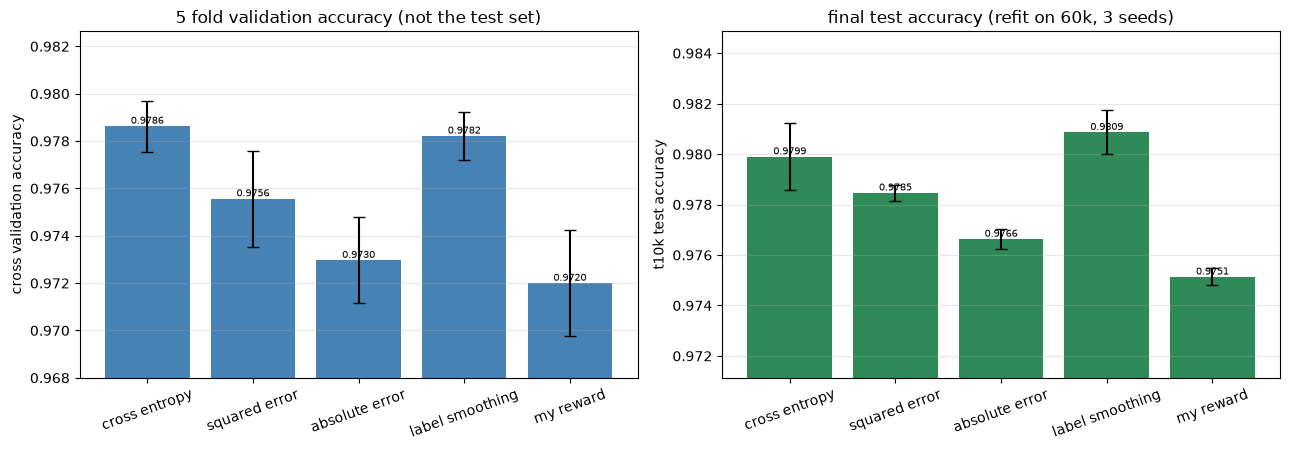

In [8]:
cv_acc, cv_err, te_acc, te_err = [], [], [], []
rews_te, roe_te = [], []
for c in criteria:
    cv_acc.append(cv[c]["acc_mean"]); cv_err.append(cv[c]["acc_std"])
    te_acc.append(final[c]["acc_mean"]); te_err.append(final[c]["acc_std"])
    rews_te.append(final[c]["reward_mean"]); roe_te.append(final[c]["reward_over_errors_mean"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].bar(criteria, cv_acc, yerr=cv_err, capsize=4, color="steelblue")
ax[0].set_ylabel("cross validation accuracy")
ax[0].set_title("5 fold validation accuracy (not the test set)")
ax[0].set_ylim(min(cv_acc) - 0.004, max(cv_acc) + 0.004)
for i, v in enumerate(cv_acc):
    ax[0].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=7)
ax[0].grid(alpha=0.3, axis="y"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(criteria, te_acc, yerr=te_err, capsize=4, color="seagreen")
ax[1].set_ylabel("t10k test accuracy")
ax[1].set_title("final test accuracy (refit on 60k, 3 seeds)")
ax[1].set_ylim(min(te_acc) - 0.004, max(te_acc) + 0.004)
for i, v in enumerate(te_acc):
    ax[1].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=7)
ax[1].grid(alpha=0.3, axis="y"); ax[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig("figures/fig_criterion_comparison.png", bbox_inches="tight")
plt.show()

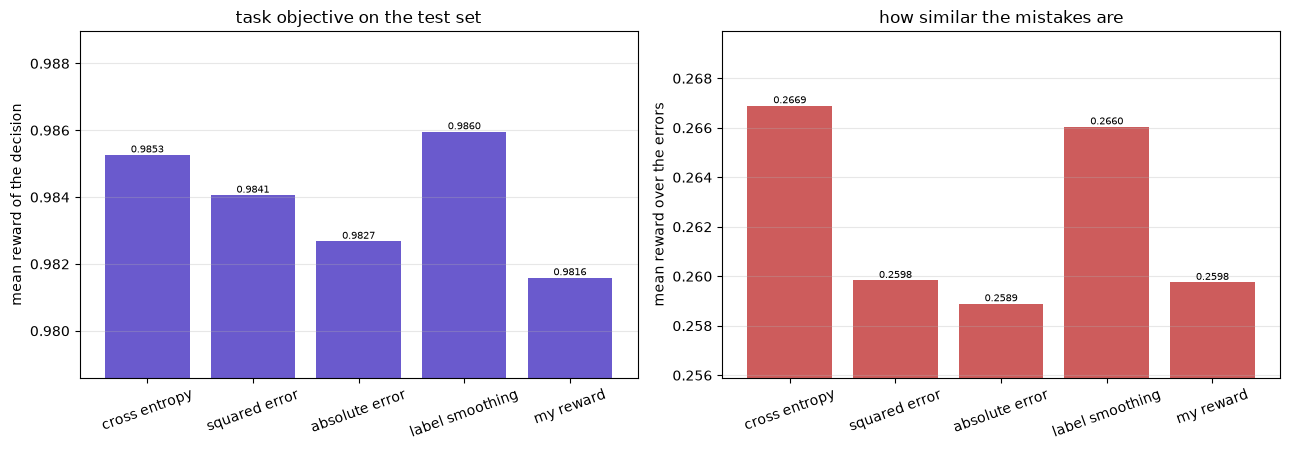

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].bar(criteria, rews_te, color="slateblue")
ax[0].set_ylabel("mean reward of the decision"); ax[0].set_title("task objective on the test set")
ax[0].set_ylim(min(rews_te) - 0.003, max(rews_te) + 0.003)
for i, v in enumerate(rews_te):
    ax[0].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=7)
ax[0].grid(alpha=0.3, axis="y"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(criteria, roe_te, color="indianred")
ax[1].set_ylabel("mean reward over the errors")
ax[1].set_title("how similar the mistakes are")
ax[1].set_ylim(min(roe_te) - 0.003, max(roe_te) + 0.003)
for i, v in enumerate(roe_te):
    ax[1].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=7)
ax[1].grid(alpha=0.3, axis="y"); ax[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig("figures/fig_task_objective.png", bbox_inches="tight")
plt.show()

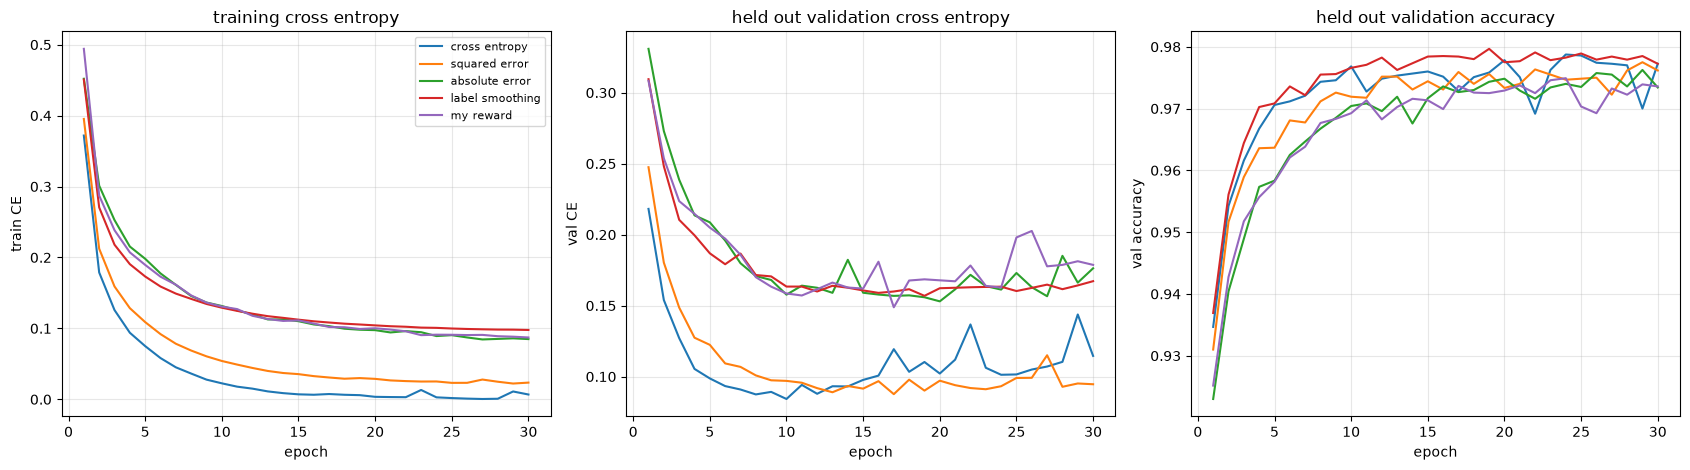

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for criterion in criteria:
    tr_curve, va_loss_curve, va_acc_curve = curves[criterion]
    e = range(1, len(tr_curve) + 1)
    ax[0].plot(e, tr_curve, label=criterion)
    ax[1].plot(e, va_loss_curve)
    ax[2].plot(e, va_acc_curve)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("train CE")
ax[0].set_title("training cross entropy"); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val CE")
ax[1].set_title("held out validation cross entropy"); ax[1].grid(alpha=0.3)
ax[2].set_xlabel("epoch"); ax[2].set_ylabel("val accuracy")
ax[2].set_title("held out validation accuracy"); ax[2].grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/fig_learning_curves.png", bbox_inches="tight")
plt.show()

max |reward - ce| cell 15.7 | max |ce seed42 - ce seed0| cell 15.0


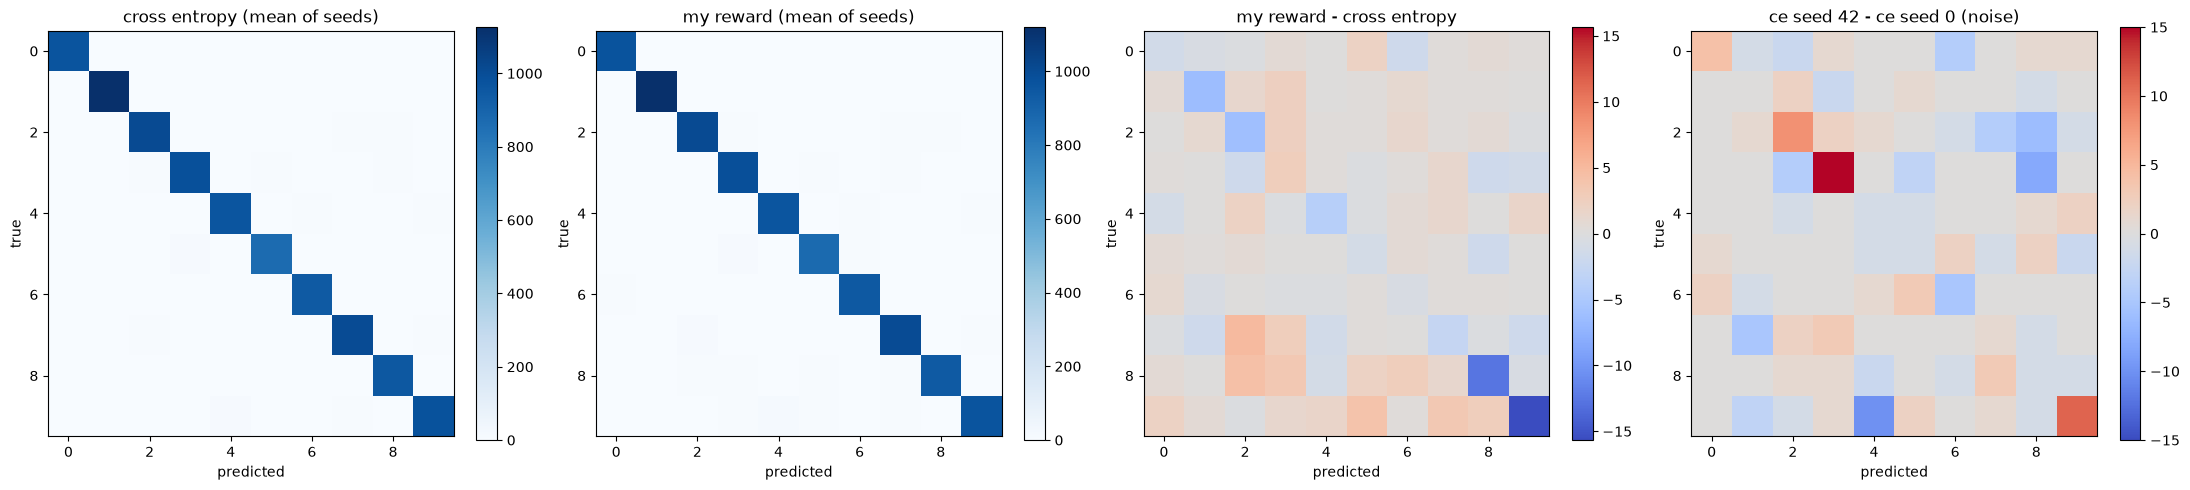

In [11]:
cm_ce = confusion_sum["cross entropy"]
cm_rew = confusion_sum["my reward"]
cm_diff = cm_rew - cm_ce
# noise baseline: same criterion, two different seeds
cm_noise = confusion_by_seed["cross entropy"][0] - confusion_by_seed["cross entropy"][1]
print("max |reward - ce| cell", round(float(np.abs(cm_diff).max()), 1),
      "| max |ce seed42 - ce seed0| cell", round(float(np.abs(cm_noise).max()), 1))

fig, ax = plt.subplots(1, 4, figsize=(22, 5))
panels = [("cross entropy (mean of seeds)", cm_ce, "Blues"),
          ("my reward (mean of seeds)", cm_rew, "Blues"),
          ("my reward - cross entropy", cm_diff, "coolwarm"),
          ("ce seed 42 - ce seed 0 (noise)", cm_noise, "coolwarm")]
for a, (title, matrix, cmap) in zip(ax, panels):
    lim = np.abs(matrix).max()
    im = a.imshow(matrix, cmap=cmap, vmin=-lim, vmax=lim) if cmap == "coolwarm" else a.imshow(matrix, cmap=cmap)
    a.set_title(title); a.set_xlabel("predicted"); a.set_ylabel("true")
    fig.colorbar(im, ax=a, fraction=0.046)
fig.tight_layout()
fig.savefig("figures/fig_confusion_matrices.png", bbox_inches="tight")
plt.show()

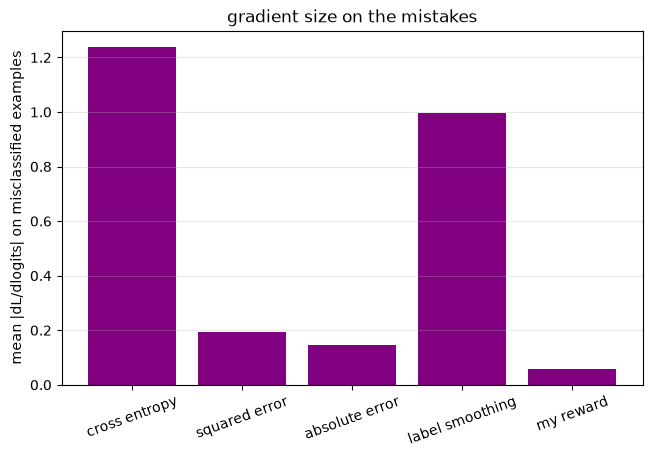

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.bar(criteria, [grad_norms[c] for c in criteria], color="purple")
ax.set_ylabel("mean |dL/dlogits| on misclassified examples")
ax.set_title("gradient size on the mistakes"); ax.grid(alpha=0.3, axis="y")
ax.tick_params(axis="x", rotation=20)
fig.savefig("figures/fig_gradient_norms.png", bbox_inches="tight")
plt.show()

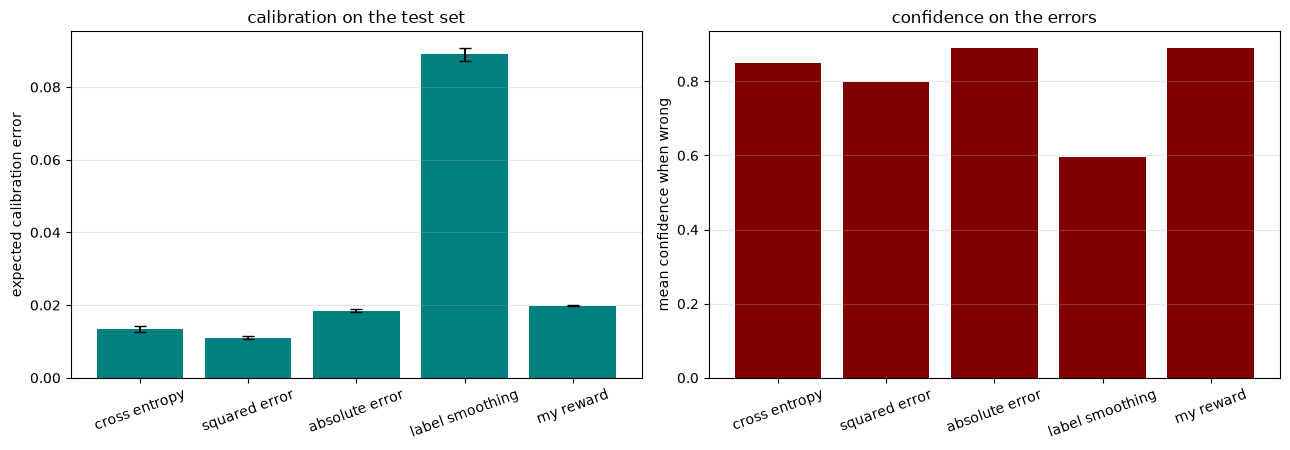

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].bar(criteria, [final[c]["ece_mean"] for c in criteria],
          yerr=[final[c]["ece_std"] for c in criteria], capsize=4, color="teal")
ax[0].set_ylabel("expected calibration error")
ax[0].set_title("calibration on the test set"); ax[0].grid(alpha=0.3, axis="y")
ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(criteria, [final[c]["conf_wrong_mean"] for c in criteria], color="maroon")
ax[1].set_ylabel("mean confidence when wrong")
ax[1].set_title("confidence on the errors"); ax[1].grid(alpha=0.3, axis="y")
ax[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig("figures/fig_calibration.png", bbox_inches="tight")
plt.show()

## 8. Metrics

In [14]:
metrics = {
    "criteria": criteria,
    "cross_validation": cv,
    "final_test": final,
    "majority_baseline_accuracy": majority_accuracy,
    "learning_curves_fold0": curves,
    "reward_matrix": reward_matrix.tolist(),
    "confusion_mean": {name: matrix.tolist() for name, matrix in confusion_sum.items()},
    "grad_norm_on_errors": grad_norms,
    "config": {"epochs": epochs, "batch_size": batch_size, "folds": number_of_folds,
               "learning_rate": learning_rate, "activation": "tanh", "seeds": seeds},
}
with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps({c: round(final[c]["acc_mean"], 4) for c in criteria}, indent=2))

{
  "cross entropy": 0.9799,
  "squared error": 0.9785,
  "absolute error": 0.9766,
  "label smoothing": 0.9809,
  "my reward": 0.9751
}
